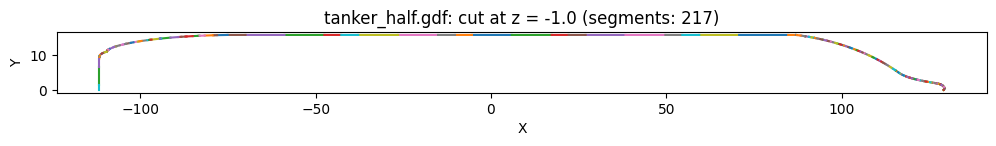

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def floats_in_line(line: str):
    """Return all floats found in a line (ignores words like 'NPAN')."""
    out = []
    for w in line.replace(",", " ").split():
        try:
            out.append(float(w))
        except ValueError:
            pass
    return out

def read_gdf_panels(gdf_path):
    lines = Path(gdf_path).read_text(errors="ignore").splitlines()

    # header is line 0 (filename/title)
    i = 1

    # ULEN GRAV (take first 2 floats on the next line that has >=2 floats)
    while i < len(lines) and len(floats_in_line(lines[i])) < 2:
        i += 1
    if i >= len(lines):
        raise ValueError("Could not find ULEN GRAV line.")
    i += 1

    # ISX ISY (next line with >=2 floats/ints)
    while i < len(lines) and len(floats_in_line(lines[i])) < 2:
        i += 1
    if i >= len(lines):
        raise ValueError("Could not find ISX ISY line.")
    i += 1

    # NPAN (next line with at least 1 float)
    while i < len(lines) and len(floats_in_line(lines[i])) < 1:
        i += 1
    if i >= len(lines):
        raise ValueError("Could not find NPAN line.")
    npan = int(floats_in_line(lines[i])[0])
    i += 1

    panels = np.zeros((npan, 4, 3), dtype=float)

    p = 0
    while p < npan and i < len(lines):
        # each panel has 4 vertex lines with 3 floats each
        verts = []
        while len(verts) < 4 and i < len(lines):
            f = floats_in_line(lines[i])
            if len(f) >= 3:
                verts.append(f[:3])
            i += 1
        if len(verts) == 4:
            panels[p] = np.array(verts, float)
            p += 1

    if p != npan:
        raise ValueError(f"Expected {npan} panels but only read {p}.")
    return panels

def slice_panels_at_z(panels, z0, tol=1e-6):
    """Intersect each quad (or tri with repeated vertex) with plane z=z0. Return XY segments."""
    segs = []

    for quad in panels:
        # treat as polygon with possible repeated last point
        pts = quad.copy()

        # build edges 0-1-2-3-0
        edges = [(0,1), (1,2), (2,3), (3,0)]
        hits = []

        for a, b in edges:
            p1, p2 = pts[a], pts[b]
            z1, z2 = p1[2], p2[2]

            # If both endpoints are on the plane, skip (rare; would be a whole edge)
            if abs(z1 - z0) < tol and abs(z2 - z0) < tol:
                continue

            # Check if segment crosses/touches z0
            if (z1 - z0) * (z2 - z0) <= 0:
                dz = z2 - z1
                if abs(dz) < tol:
                    continue
                t = (z0 - z1) / dz
                if -tol <= t <= 1 + tol:
                    x = p1[0] + t * (p2[0] - p1[0])
                    y = p1[1] + t * (p2[1] - p1[1])
                    hits.append((x, y))

        # dedupe near-identical hit points
        uniq = []
        for h in hits:
            if not any((h[0]-u[0])**2 + (h[1]-u[1])**2 < (10*tol)**2 for u in uniq):
                uniq.append(h)

        # typical result: 0 or 2 intersections
        if len(uniq) >= 2:
            segs.append((uniq[0], uniq[1]))

    return segs

# --------- set these ----------
gdf_file = "tanker_half.gdf"
z0 = -1.0
# ------------------------------

panels = read_gdf_panels(gdf_file)
segs = slice_panels_at_z(panels, z0)

plt.figure(figsize=(12,6))
for (x1, y1), (x2, y2) in segs:
    plt.plot([x1, x2], [y1, y2])

plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("X")
plt.ylabel("Y")
plt.title(f"{Path(gdf_file).name}: cut at z = {z0} (segments: {len(segs)})")
plt.show()
